In [116]:
import numpy as np
import json
from pathlib import Path
from natsort import natsorted
from collections import defaultdict
from tqdm.notebook import tqdm
import csv

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
p_id_to_parish = {}
with open("data/csv/parish.csv", "r") as fp:
    reader = csv.reader(fp)
    cols = next(reader)
    for row in reader:
        p_id_to_parish[int(row[0])] = row[2]


with open("data/json/pl_id_to_pl.json", "r") as fp:
    p_id_to_parish.update({int(k): v for k, v in json.load(fp).items()})

In [4]:
migration_events_dir = Path(
    "outputs/json/all_migration_events_parish_splits_duplicate_info"
)

In [5]:
parish_event_files = natsorted(list(migration_events_dir.glob("*.jsonl")))

In [117]:
immigration_counts = {}

for parish_event_file in tqdm(parish_event_files):
    p_id = int(parish_event_file.stem.split("_")[0])
    p_dict = defaultdict(int)
    with open(parish_event_file, "r") as fp:
        for row in fp:
            if (
                'duplicate": true' in row
                or 'in/out": "in"' not in row
            ):
                continue

            row_dict = json.loads(row)
            row_data = row_dict["row_data"]
            if (
                len(tuple(c for c in "".join(row_data) if c.isalpha())) < 4
                or row_dict["year_prediction"] == 0
            ):
                continue

            p_dict[row_dict["year_prediction"]] += 1

    immigration_counts[p_id] = {
        "years": p_dict,
        "total": sum(p_dict.values())
    }

  0%|          | 0/468 [00:00<?, ?it/s]

In [118]:
top_ten_parishes = {
    p_id_to_parish[c[0]]: c[1]
    for c in sorted(
        immigration_counts.items(),
        key=lambda x: x[1]["total"],
        reverse=True
    )[:11]
}

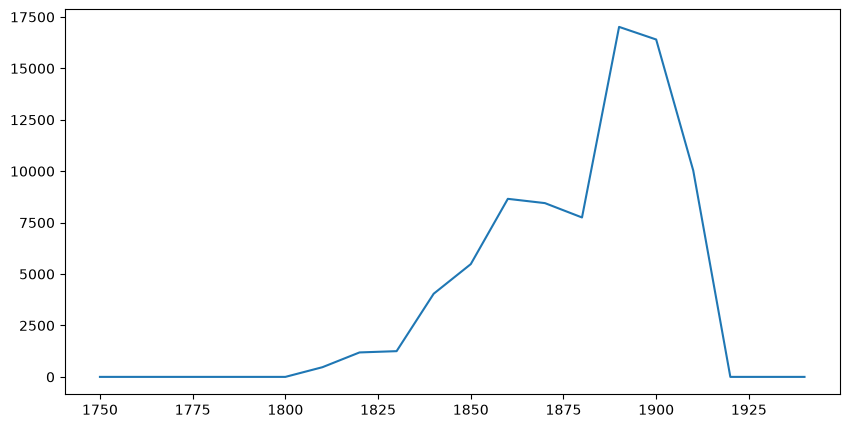

In [119]:
years = []
for year, count in top_ten_parishes["Tampereen tuomiokirkkoseurakunta"][
    "years"
].items():
    years += [year] * count

bins = range(1750, 1951, 10)

binned = np.histogram(years, bins)[0]
plt.subplots(1, 1, figsize=(10, 5))
ax = sns.lineplot({b: val for b, val in zip(bins, binned)})

<Axes: >

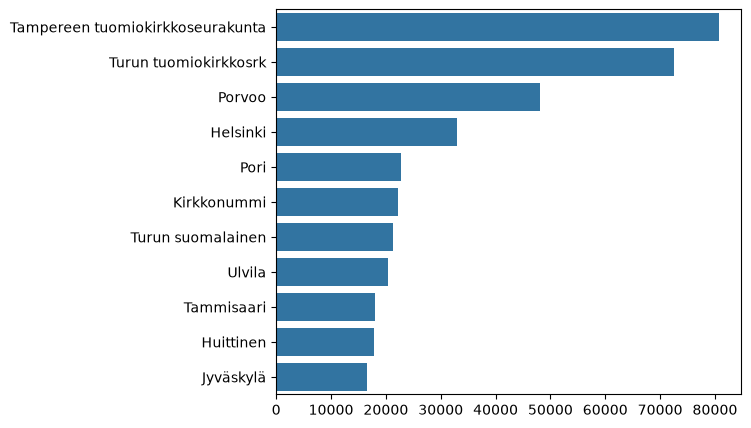

In [120]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.barplot(
    {k: v["total"] for k, v in top_ten_parishes.items()},
    ax=ax,
    orient="h"
)

<Axes: ylabel='Density'>

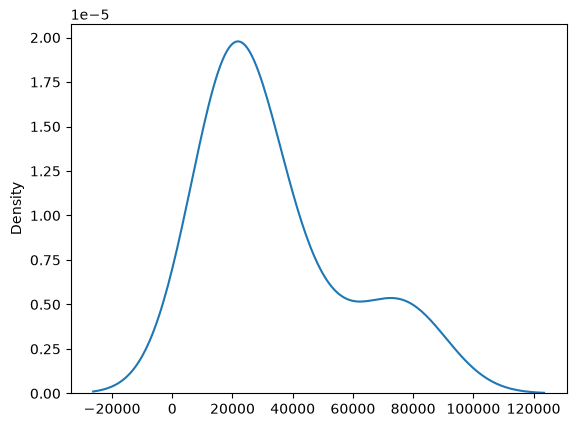

In [121]:
sns.kdeplot(
    {k: v["total"] for k, v in top_ten_parishes.items()},
)